importation

In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import os

Chargement et noms de colonnes

In [10]:
df = pd.read_csv('wdbc.data', header=None)
col_names = ['id', 'diagnosis',
             'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
             'smoothness_mean', 'compactness_mean', 'concavity_mean',
             'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
             'radius_se', 'texture_se', 'perimeter_se', 'area_se',
             'smoothness_se', 'compactness_se', 'concavity_se',
             'concave points_se', 'symmetry_se', 'fractal_dimension_se',
             'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
             'smoothness_worst', 'compactness_worst', 'concavity_worst',
             'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
df.columns = col_names
df.drop('id', axis=1, inplace=True)
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


Exploration initiale

In [11]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['diagnosis'].value_counts(normalize=True) * 100)

(569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  56

Statistiques et skewness

In [12]:
print(df.describe())
num_cols = df.select_dtypes(include=['float64']).columns
for col in list(num_cols)[:5]:
    print(f"{col}: skew={skew(df[col]):.3f}, kurtosis={kurtosis(df[col]):.3f}")

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

Comparaison par classe

In [13]:
grouped = df.groupby('diagnosis').mean()
diff = abs(grouped.loc['M'] - grouped.loc['B']).sort_values(ascending=False)
print(diff.head(5))

area_worst         863.386881
area_mean          515.586219
perimeter_worst     54.364392
area_se             51.537257
perimeter_mean      37.289971
dtype: float64


Détection outliers et boxplots

radius_mean: 14 outliers (2.46%)


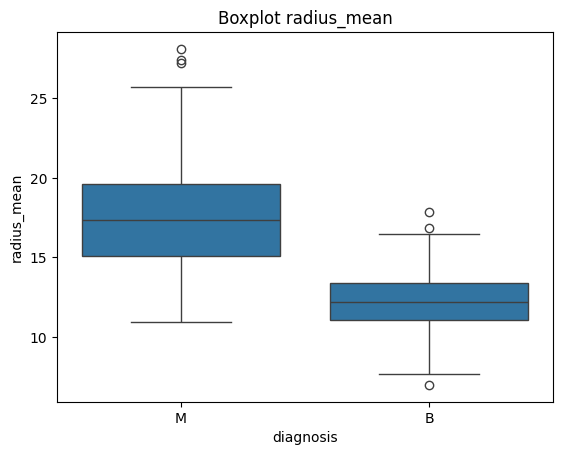

area_mean: 25 outliers (4.39%)


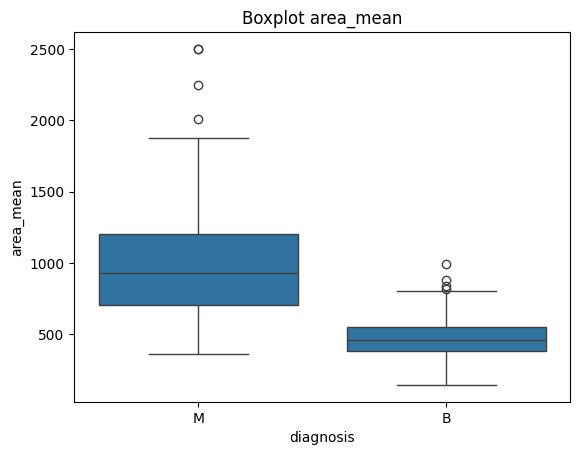

smoothness_mean: 6 outliers (1.05%)


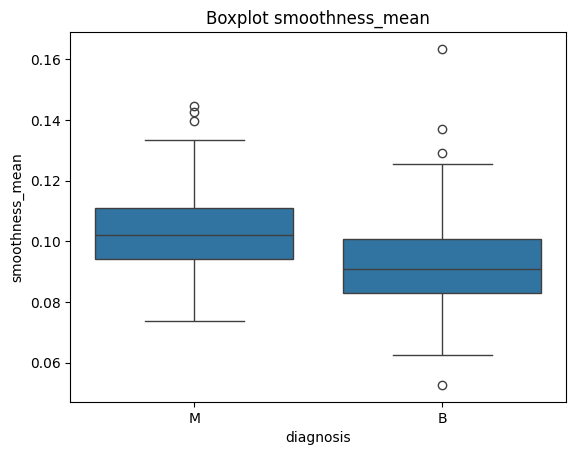

In [14]:
def iqr_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5*IQR
    high = Q3 + 1.5*IQR
    out = data[(data[col] < low) | (data[col] > high)]
    return len(out), len(out)/len(data)*100

os.makedirs('graphs', exist_ok=True)
for col in ['radius_mean', 'area_mean', 'smoothness_mean']:
    n, p = iqr_outliers(df, col)
    print(f"{col}: {n} outliers ({p:.2f}%)")
    plt.figure()
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'Boxplot {col}')
    plt.savefig(f'graphs/boxplot_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()

Transformation log

radius_se: skew avant 3.080 → après 1.709


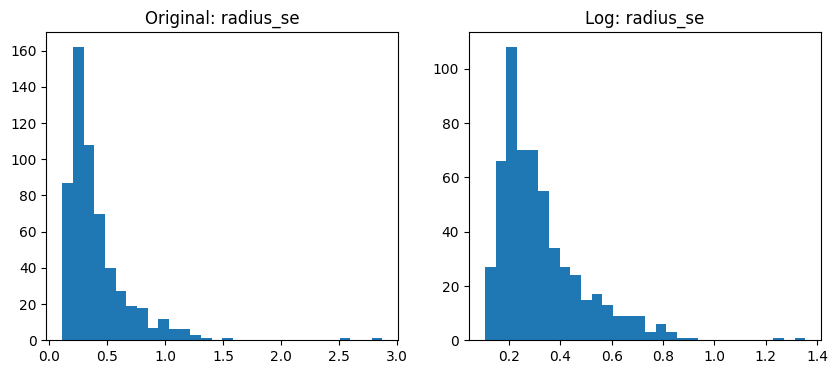

perimeter_se: skew avant 3.435 → après 1.023


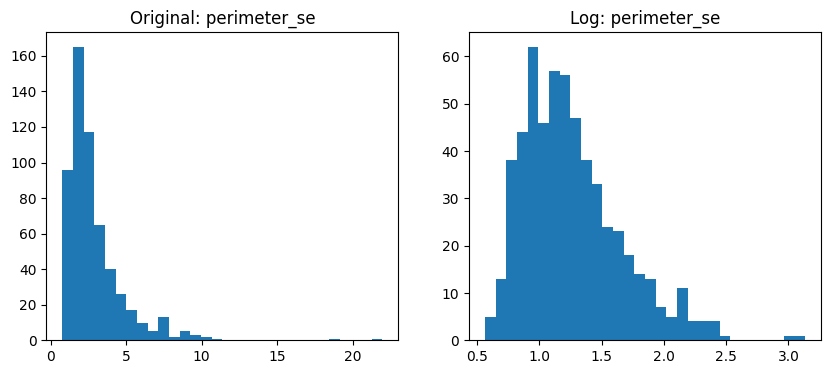

area_se: skew avant 5.433 → après 0.845


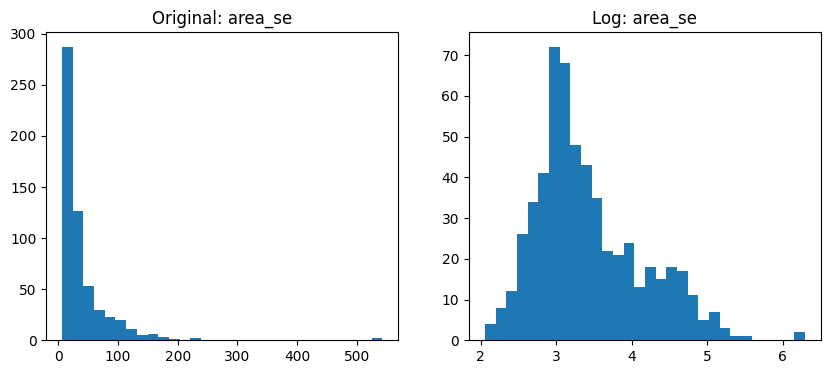

smoothness_se: skew avant 2.308 → après 2.277


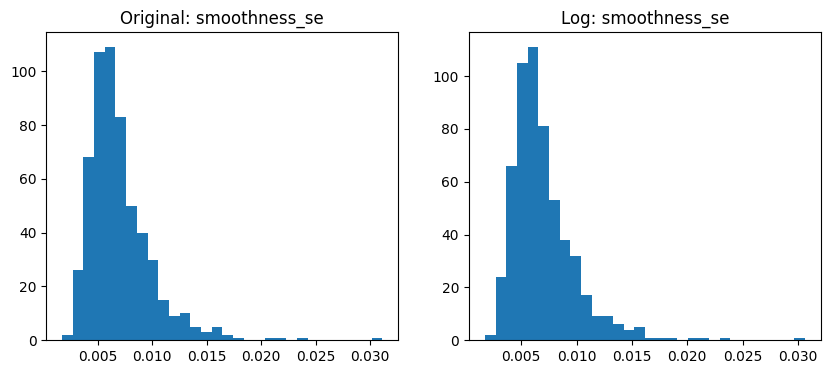

concavity_se: skew avant 5.097 → après 4.221


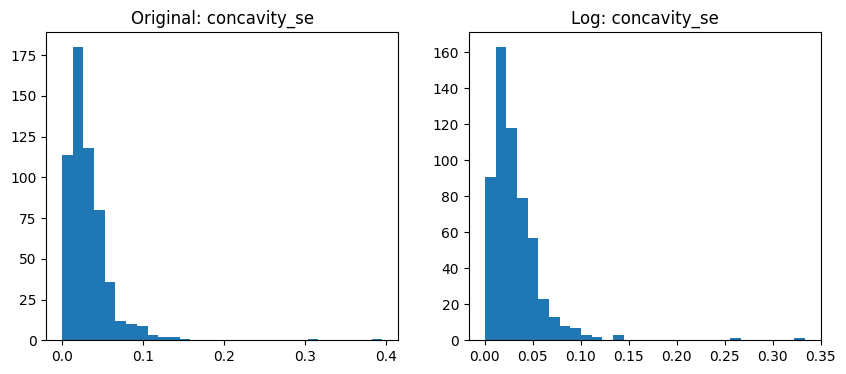

symmetry_se: skew avant 2.189 → après 2.130


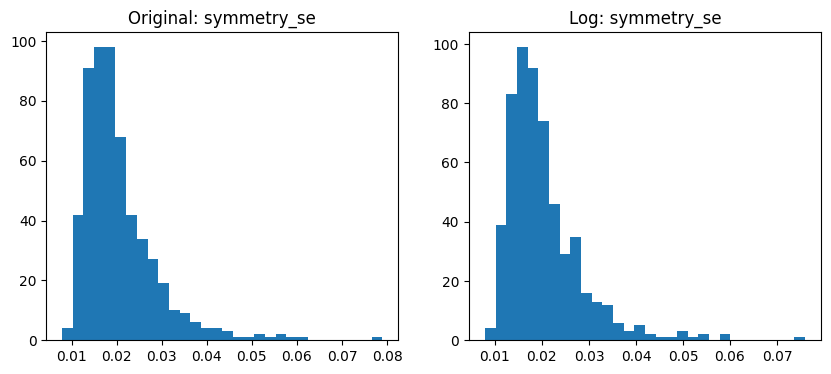

fractal_dimension_se: skew avant 3.914 → après 3.864


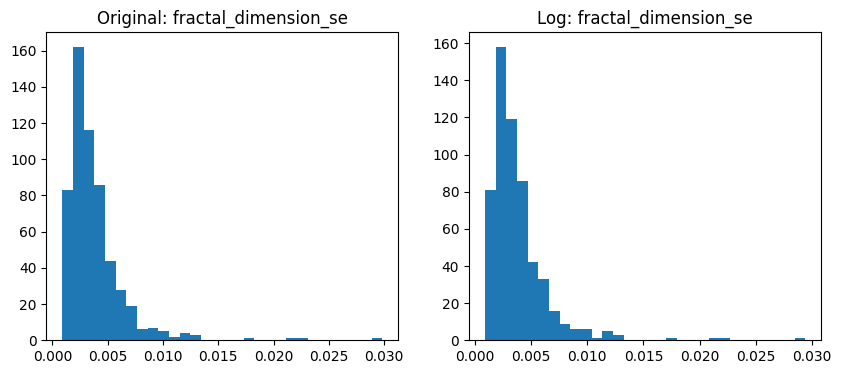

In [15]:
skew_vals = df[num_cols].apply(lambda x: skew(x.dropna()))
high_skew = skew_vals[abs(skew_vals) > 2].index.tolist()
for var in high_skew:
    df[f'{var}_log'] = np.log1p(df[var])
    print(f"{var}: skew avant {skew(df[var]):.3f} → après {skew(df[f'{var}_log']):.3f}")
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
    ax1.hist(df[var], bins=30)
    ax1.set_title(f'Original: {var}')
    ax2.hist(df[f'{var}_log'], bins=30)
    ax2.set_title(f'Log: {var}')
    plt.savefig(f'graphs/log_{var}.png', dpi=300, bbox_inches='tight')
    plt.show()

sauvegarde finale 

In [16]:
df.to_csv('breast_cancer_cleaned.csv', index=False)
print("Fichier sauvegardé : breast_cancer_cleaned.csv")

Fichier sauvegardé : breast_cancer_cleaned.csv


In [17]:
# Cellule : Chargement du dataset nettoyé
df = pd.read_csv('breast_cancer_cleaned.csv')
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (569, 38)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,concave points_worst,symmetry_worst,fractal_dimension_worst,radius_se_log,perimeter_se_log,area_se_log,smoothness_se_log,concavity_se_log,symmetry_se_log,fractal_dimension_se_log
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,0.2654,0.4601,0.11890,0.739554,2.260617,5.039547,0.006379,0.052336,0.029588,0.006174
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,0.1860,0.2750,0.08902,0.434053,1.481150,4.318554,0.005211,0.018429,0.013794,0.003526
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,0.2430,0.3613,0.08758,0.557098,1.720084,4.554193,0.006131,0.037604,0.022251,0.004561
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,0.2575,0.6638,0.17300,0.402527,1.491780,3.340385,0.009069,0.055066,0.057920,0.009166
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,0.1625,0.2364,0.07678,0.563722,1.862218,4.558498,0.011424,0.055321,0.017408,0.005102


PARTIE 3 – FEATURE ENGINEERING


Question 3.1 – Création d’une variable de tendance

In [18]:
# Cellule 3.1.1 : Création de la variable de tendance 'area_trend'
df['area_trend'] = df['area_worst'] - df['area_mean']

# Statistiques par classe
trend_stats = df.groupby('diagnosis')['area_trend'].agg(['mean', 'median', 'std'])
print(trend_stats)

                 mean  median         std
diagnosis                                
B           96.109244   88.20   42.999351
M          443.909906  365.15  303.153809


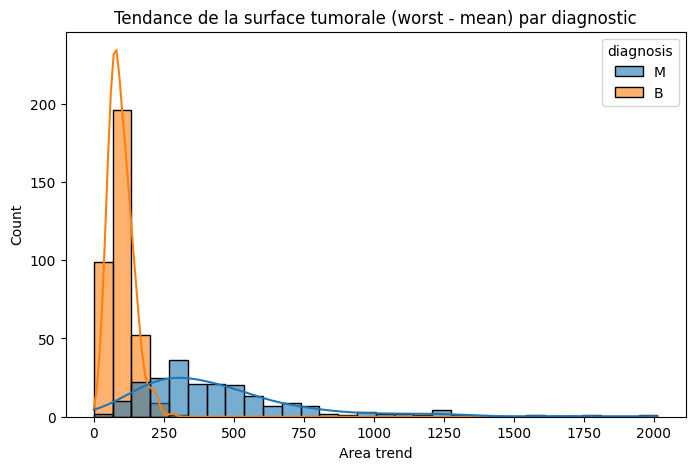

In [19]:
# Cellule 3.1.2 : Histogramme + KDE de area_trend par classe
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='area_trend', hue='diagnosis', kde=True, bins=30, alpha=0.6)
plt.title('Tendance de la surface tumorale (worst - mean) par diagnostic')
plt.xlabel('Area trend')
plt.savefig('graphs/area_trend_hist.png', dpi=300, bbox_inches='tight')
plt.show()

Question 3.2 – Création de ratios / variables dérivées

In [20]:
# Cellule 3.2.1 : Création des ratios
df['ratio_perimeter_area'] = df['perimeter_mean'] / (df['area_mean'] + 1e-6)
df['ratio_concavity'] = df['concavity_mean'] / (df['compactness_mean'] + 1e-6)

# Statistiques par classe
ratios = ['ratio_perimeter_area', 'ratio_concavity']
for r in ratios:
    print(f"\n{r} :")
    print(df.groupby('diagnosis')[r].agg(['mean', 'median', 'std']))


ratio_perimeter_area :
               mean    median       std
diagnosis                              
B          0.176477  0.171288  0.028502
M          0.125965  0.121338  0.023412

ratio_concavity :
               mean    median       std
diagnosis                              
B          0.513209  0.493769  0.298377
M          1.090725  1.081280  0.277205


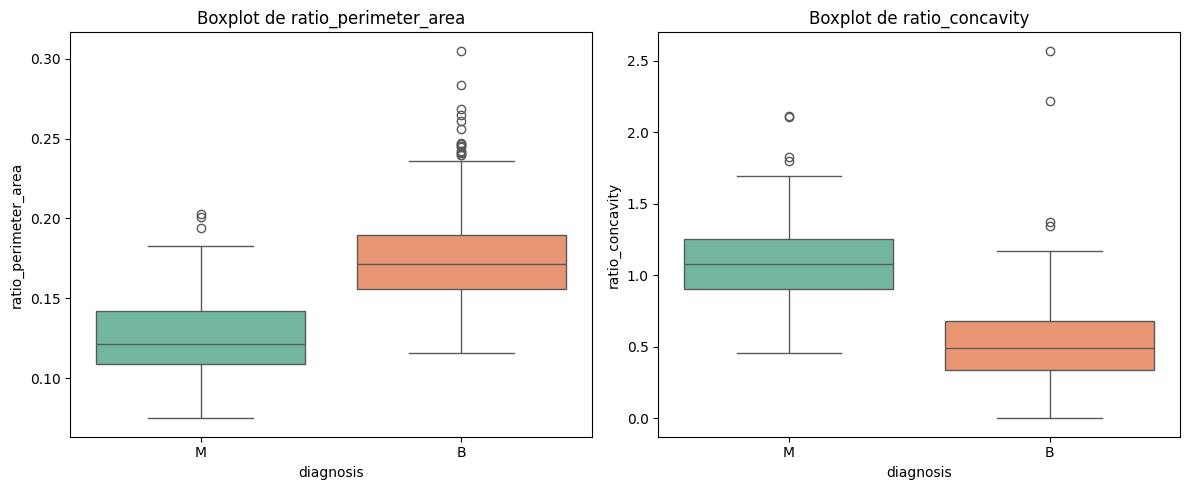

In [21]:
# Cellule 3.2.2 : Boxplots comparatifs des ratios
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, r in zip(axes, ratios):
    sns.boxplot(data=df, x='diagnosis', y=r, hue='diagnosis', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'Boxplot de {r}')
plt.tight_layout()
plt.savefig('graphs/ratios_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

Question 3.3 – Agrégations multi-colonnes

In [22]:
# Cellule 3.3.1 : Compter le nombre de features worst au-dessus du 75e percentile
worst_cols = [col for col in df.columns if col.endswith('_worst')]
thresholds = df[worst_cols].quantile(0.75)
df['n_severe_features'] = (df[worst_cols] > thresholds).sum(axis=1)

# Distribution par classe
print(df.groupby('diagnosis')['n_severe_features'].describe())

           count      mean       std  min  25%  50%  75%   max
diagnosis                                                     
B          357.0  0.661064  1.035858  0.0  0.0  0.0  1.0   6.0
M          212.0  5.584906  2.560613  0.0  4.0  5.0  7.0  10.0


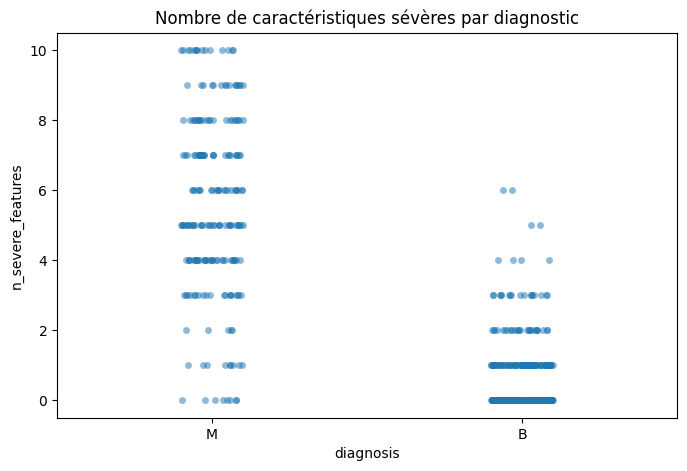

In [23]:
# Cellule 3.3.2 : Scatter plot n_severe_features vs cible (avec jitter)
plt.figure(figsize=(8,5))
sns.stripplot(data=df, x='diagnosis', y='n_severe_features', jitter=True, alpha=0.5)
plt.title('Nombre de caractéristiques sévères par diagnostic')
plt.savefig('graphs/n_severe_features.png', dpi=300, bbox_inches='tight')
plt.show()

Question 3.4 – Transformations logarithmiques (complément)

In [5]:
# Cellule 3.4.1 - Création des transformations log pour les variables asymétriques
import pandas as pd
import numpy as np
from scipy.stats import skew

# Chargement du dataset
df = pd.read_csv('breast_cancer_cleaned.csv')   

# 1. Sélectionner les variables numériques (sauf la cible et les colonnes déjà log)
exclude = ['diagnosis', 'target']  # target sera créée plus tard
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Enlever les colonnes qui contiennent déjà '_log' pour ne pas les re-loguer
numeric_cols = [col for col in numeric_cols if '_log' not in col and col not in exclude]

# 2. Calculer le skewness initial
skewness_initial = {col: skew(df[col].dropna()) for col in numeric_cols}

# 3. Identifier celles avec |skewness| > 2
high_skew = [col for col in numeric_cols if abs(skewness_initial[col]) > 2]
print(f"Variables avec |skewness| > 2 : {high_skew}")

# 4. Créer les colonnes log (si elles n'existent pas déjà)
for col in high_skew:
    log_col = col + '_log'
    if log_col not in df.columns:
        df[log_col] = np.log1p(df[col])   # log(1+x) pour gérer les zéros
        print(f"Création de {log_col} (skewness initial : {skewness_initial[col]:.2f})")

# 5. Calculer le nouveau skewness après transformation
skewness_after = {}
for col in high_skew:
    log_col = col + '_log'
    skewness_after[col] = skew(df[log_col].dropna())

# 6. Tableau comparatif
comparison = pd.DataFrame({
    'Variable': high_skew,
    'Skewness AVANT': [skewness_initial[col] for col in high_skew],
    'Skewness APRÈS': [skewness_after[col] for col in high_skew],
    'Amélioration': [skewness_initial[col] - skewness_after[col] for col in high_skew]
})
print("\nTableau comparatif :")
print(comparison)

Variables avec |skewness| > 2 : ['radius_se', 'perimeter_se', 'area_se', 'smoothness_se', 'concavity_se', 'symmetry_se', 'fractal_dimension_se']

Tableau comparatif :
               Variable  Skewness AVANT  Skewness APRÈS  Amélioration
0             radius_se        3.080464        1.708897      1.371567
1          perimeter_se        3.434530        1.022670      2.411860
2               area_se        5.432816        0.845063      4.587753
3         smoothness_se        2.308344        2.277371      0.030974
4          concavity_se        5.096981        4.220574      0.876407
5           symmetry_se        2.189342        2.130239      0.059102
6  fractal_dimension_se        3.913617        3.864152      0.049465


Variables avec |skew| > 2 : ['radius_se', 'perimeter_se', 'area_se', 'smoothness_se', 'concavity_se', 'symmetry_se', 'fractal_dimension_se']
Génération du graphique pour : radius_se


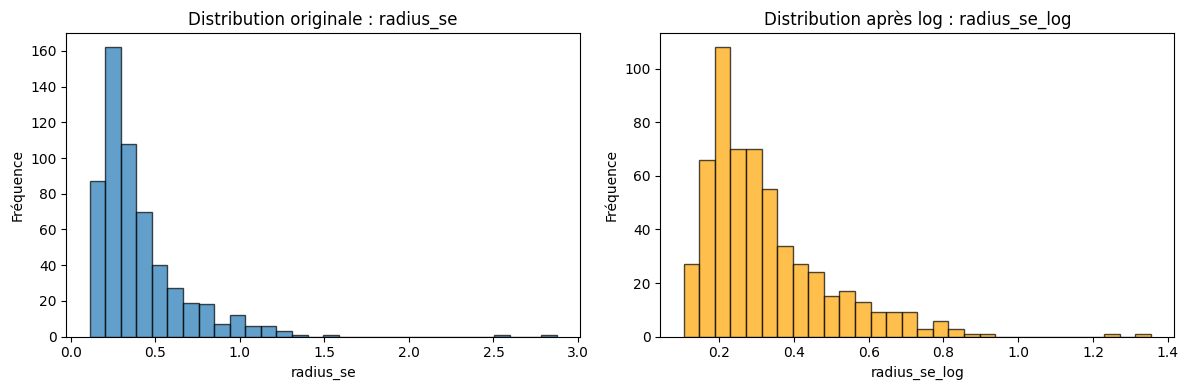

Graphique sauvegardé : graphs/log_radius_se.png


In [3]:
# Cellule autonome pour 3.4 : transformations log et graphique
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
import os

# Charger le dataset
df = pd.read_csv('breast_cancer_cleaned.csv')
# Créer le dossier graphs
os.makedirs('graphs', exist_ok=True)

# Sélectionner les colonnes numériques (sauf la cible diagnosis)
exclude = ['diagnosis']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if '_log' not in col and col not in exclude]

# Calcul du skewness initial
skewness_initial = {}
for col in numeric_cols:
    skewness_initial[col] = skew(df[col].dropna())

# Identifier les variables avec |skew| > 2
high_skew = [col for col in numeric_cols if abs(skewness_initial[col]) > 2]
print(f"Variables avec |skew| > 2 : {high_skew}")

# Créer les colonnes log si nécessaire
for col in high_skew:
    log_col = col + '_log'
    if log_col not in df.columns:
        df[log_col] = np.log1p(df[col])

# Sélectionner une variable pour le graphique (par exemple la première de high_skew)
if high_skew:
    var = high_skew[0]
    log_var = var + '_log'
else:
    # Fallback : utiliser une variable manuelle (par exemple area_mean si elle existe)
    var = 'area_mean'
    log_var = var + '_log'
    if log_var not in df.columns:
        df[log_var] = np.log1p(df[var])

print(f"Génération du graphique pour : {var}")

# Graphique côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df[var].dropna(), bins=30, edgecolor='black', alpha=0.7)
ax1.set_title(f'Distribution originale : {var}')
ax1.set_xlabel(var)
ax1.set_ylabel('Fréquence')

ax2.hist(df[log_var].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
ax2.set_title(f'Distribution après log : {log_var}')
ax2.set_xlabel(log_var)
ax2.set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig(f'graphs/log_{var}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Graphique sauvegardé : graphs/log_{var}.png")

Question 3.5 – Bilan du Feature Engineering


In [25]:
# Cellule 3.5.1 : Compter les nouvelles variables créées
original_features = set(pd.read_csv('breast_cancer_cleaned.csv').columns)  # avant FE
current_features = set(df.columns)
new_features = current_features - original_features
print(f"Nouvelles variables créées : {len(new_features)}")
print("Liste :", list(new_features))

# Dimensions avant / après
print(f"Dimensions avant FE : {pd.read_csv('breast_cancer_cleaned.csv').shape}")
print(f"Dimensions après FE : {df.shape}")

Nouvelles variables créées : 5
Liste : ['ratio_concavity', 'ratio_perimeter_area', 'n_severe_features', 'area_trend_log', 'area_trend']
Dimensions avant FE : (569, 38)
Dimensions après FE : (569, 43)


PARTIE 4 – ANALYSE EXPLORATOIRE AVANCÉE (EDA)

Question 4.1 – Matrice de corrélation

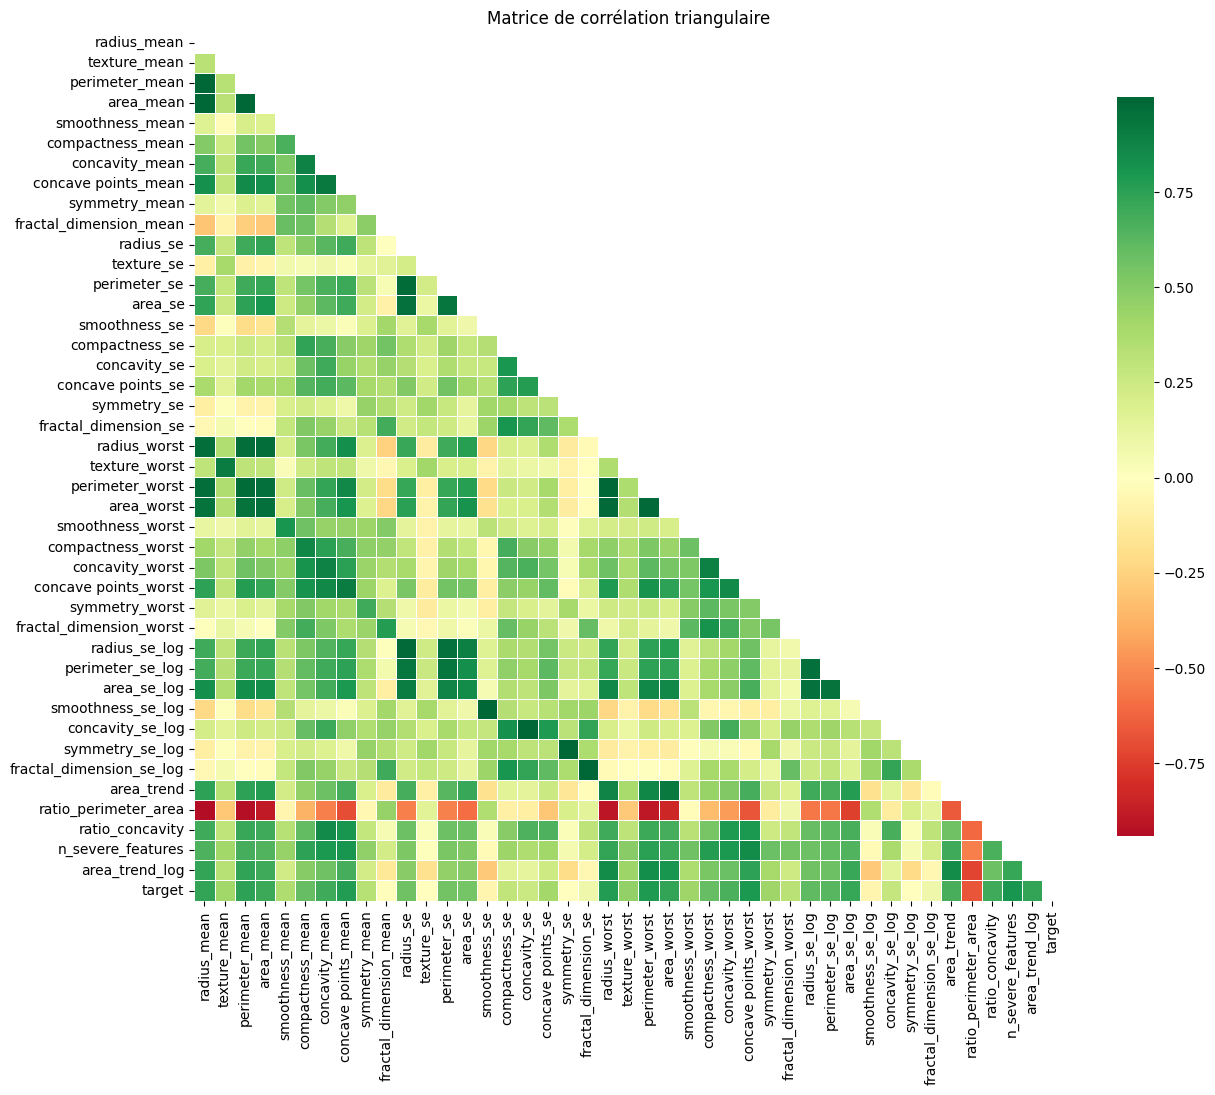


Paires de variables avec |corrélation| > 0.9 :
Variable 1                     Variable 2                            r
----------------------------------------------------------------------
radius_mean                    perimeter_mean                    0.998
radius_mean                    area_mean                         0.987
radius_mean                    radius_worst                      0.970
radius_mean                    perimeter_worst                   0.965
radius_mean                    area_worst                        0.941
radius_mean                    ratio_perimeter_area             -0.942
texture_mean                   texture_worst                     0.912
perimeter_mean                 area_mean                         0.987
perimeter_mean                 radius_worst                      0.969
perimeter_mean                 perimeter_worst                   0.970
perimeter_mean                 area_worst                        0.942
perimeter_mean               

In [7]:
# Cellule 4.1 - Matrice de corrélation et paires avec |r| > 0.9
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset (adapter le nom si nécessaire)
df = pd.read_csv('breast_cancer_featured.csv')

# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

# --- Heatmap triangulaire ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink":0.8})
plt.title('Matrice de corrélation triangulaire')
plt.savefig('graphs/corr_matrix_triangular.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Liste des paires avec |r| > 0.9 ---
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

print("\nPaires de variables avec |corrélation| > 0.9 :")
print(f"{'Variable 1':<30} {'Variable 2':<30} {'r':>8}")
print("-" * 70)
for v1, v2, r in high_corr_pairs:
    print(f"{v1:<30} {v2:<30} {r:>8.3f}")

# Sauvegarde des paires (optionnel)
with open('graphs/high_corr_pairs.txt', 'w') as f:
    f.write("Paires avec |r| > 0.9 :\n")
    for v1, v2, r in high_corr_pairs:
        f.write(f"{v1} & {v2} : {r:.3f}\n")

Question 4.2 – Corrélations avec la variable cible

Top 10 des variables les plus corrélées avec la cible :
n_severe_features       0.803876
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_trend_log          0.729859
area_se_log             0.724995
dtype: float64


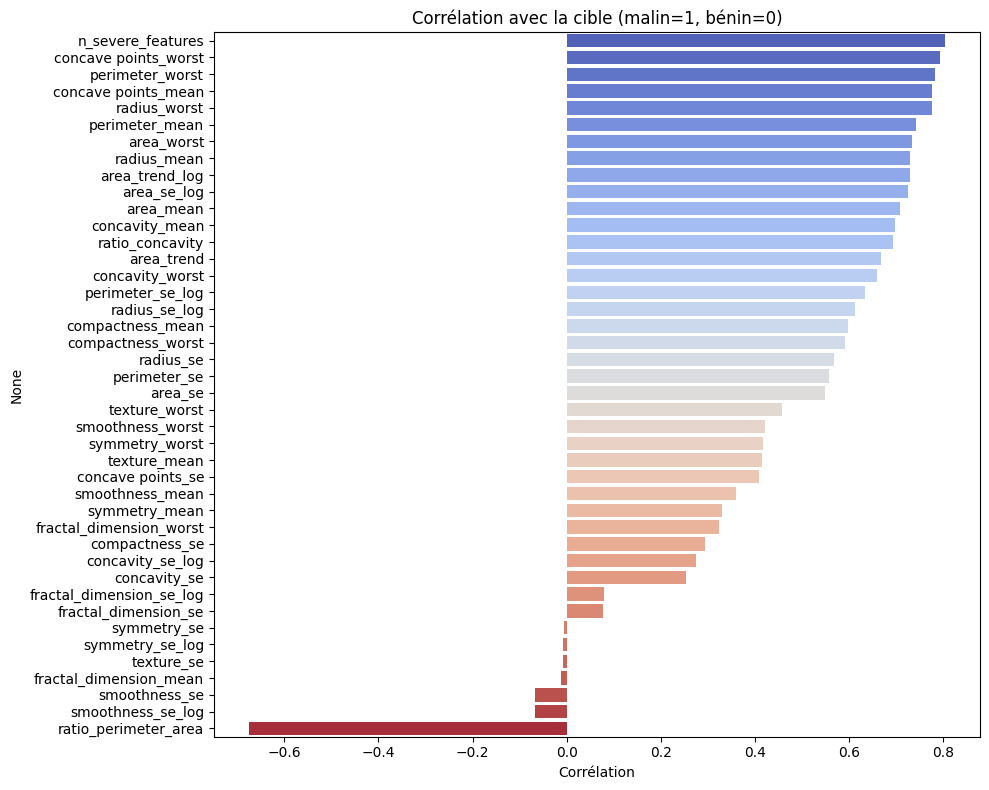

In [27]:
# Cellule 4.2.1 : Corrélations avec diagnosis (transformée en numérique : M=1, B=0)

# Création de la cible numérique
df['target'] = (df['diagnosis'] == 'M').astype(int)

# Sélection des colonnes numériques (exclure 'target' pour éviter l'autocorrélation)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != 'target']

# Calcul des corrélations avec la cible
target_corr = df[num_cols].corrwith(df['target']).sort_values(ascending=False)

# Affichage des 10 premières
print("Top 10 des variables les plus corrélées avec la cible :")
print(target_corr.head(10))

# Heatmap verticale triée (version corrigée sans warning)
plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, 
            hue=target_corr.index, palette='coolwarm', legend=False)
plt.title('Corrélation avec la cible (malin=1, bénin=0)')
plt.xlabel('Corrélation')
plt.tight_layout()
plt.savefig('graphs/target_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Question 4.3 – Distributions univariées

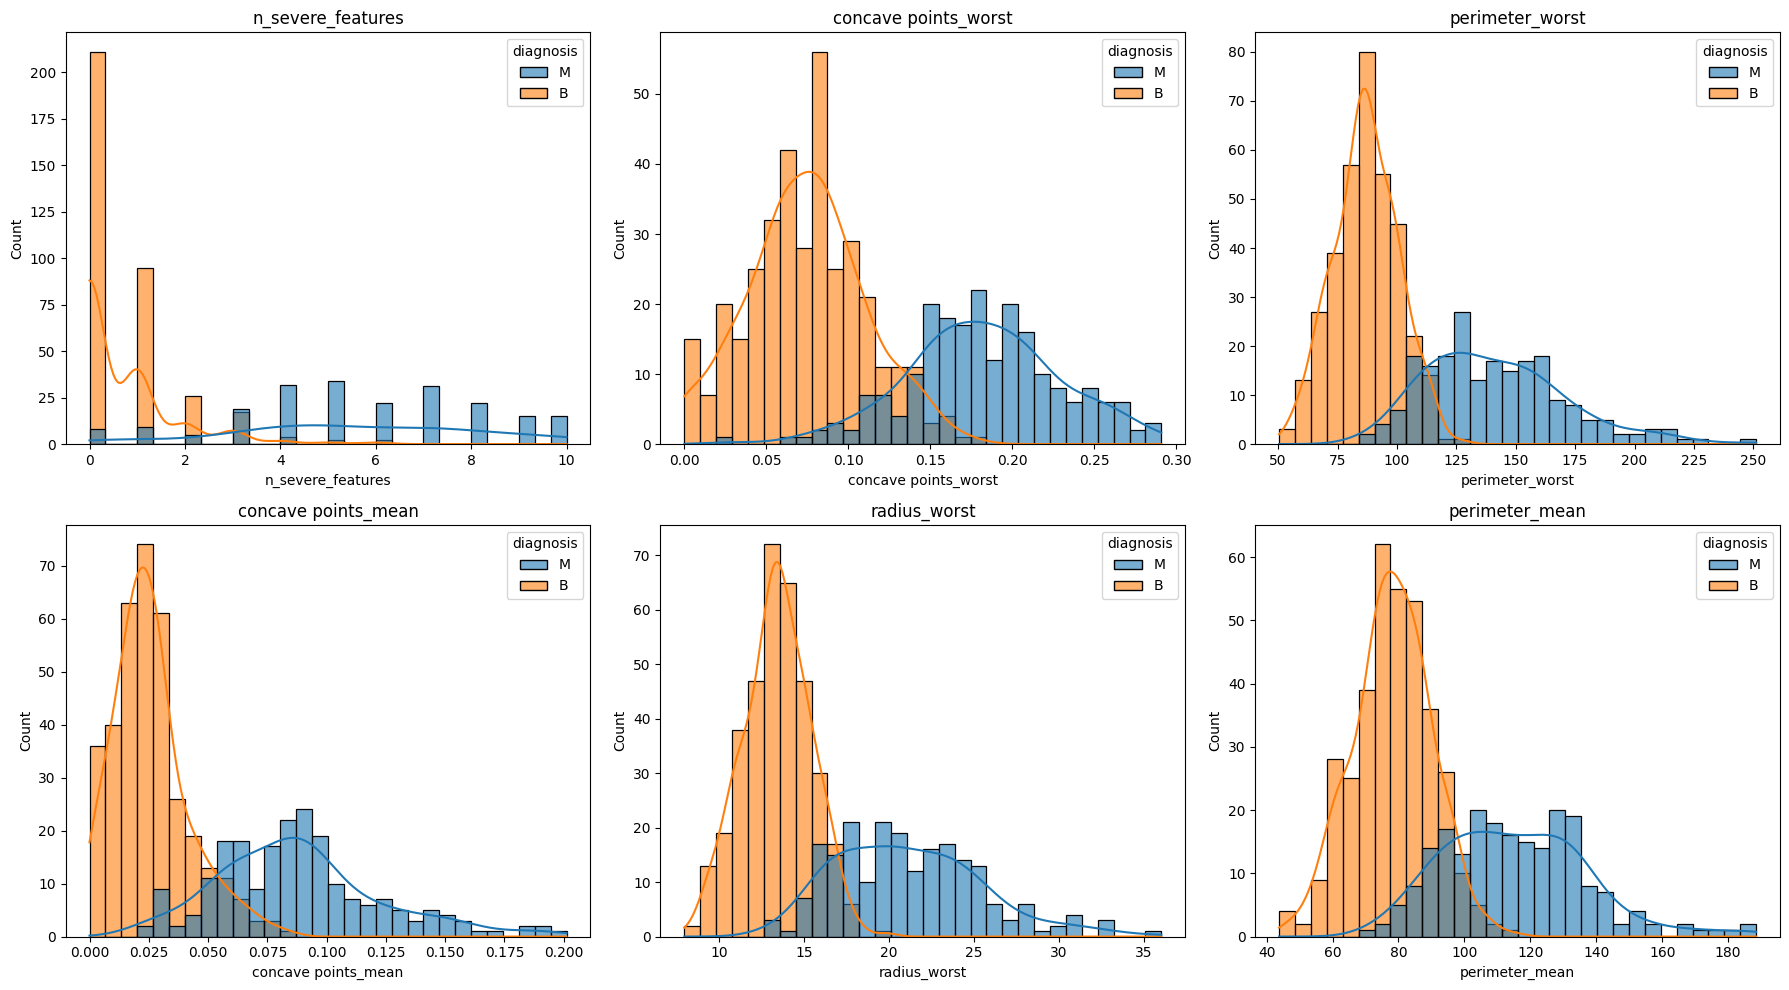

In [28]:
# Cellule 4.3.1 : Grille de sous-graphiques pour les 6 variables les plus importantes
top_vars = target_corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    sns.histplot(data=df, x=var, hue='diagnosis', kde=True, bins=30, ax=axes[i], alpha=0.6)
    axes[i].set_title(var)

plt.tight_layout()
plt.savefig('graphs/univariate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# Cellule 4.3.2 : Tableau récapitulatif (forme, outliers, interprétation)
summary = []
for var in top_vars:
    skew_val = skew(df[var])
    # Détection simple d'outliers (IQR)
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[var] < Q1 - 1.5*IQR) | (df[var] > Q3 + 1.5*IQR)).sum()
    shape = "asymétrique droite" if skew_val > 0.5 else ("asymétrique gauche" if skew_val < -0.5 else "symétrique")
    interp = "plus élevée pour les tumeurs malignes" if target_corr[var] > 0 else "plus élevée pour les bénignes"
    summary.append([var, shape, outliers, interp])

summary_df = pd.DataFrame(summary, columns=['Variable', 'Forme', 'Outliers (n)', 'Interprétation'])
print(summary_df)

               Variable               Forme  Outliers (n)  \
0     n_severe_features  asymétrique droite             0   
1  concave points_worst          symétrique             0   
2       perimeter_worst  asymétrique droite            15   
3   concave points_mean  asymétrique droite            10   
4          radius_worst  asymétrique droite            17   
5        perimeter_mean  asymétrique droite            13   

                          Interprétation  
0  plus élevée pour les tumeurs malignes  
1  plus élevée pour les tumeurs malignes  
2  plus élevée pour les tumeurs malignes  
3  plus élevée pour les tumeurs malignes  
4  plus élevée pour les tumeurs malignes  
5  plus élevée pour les tumeurs malignes  


Question 4.4 – Analyse bivariée (scatter plots)

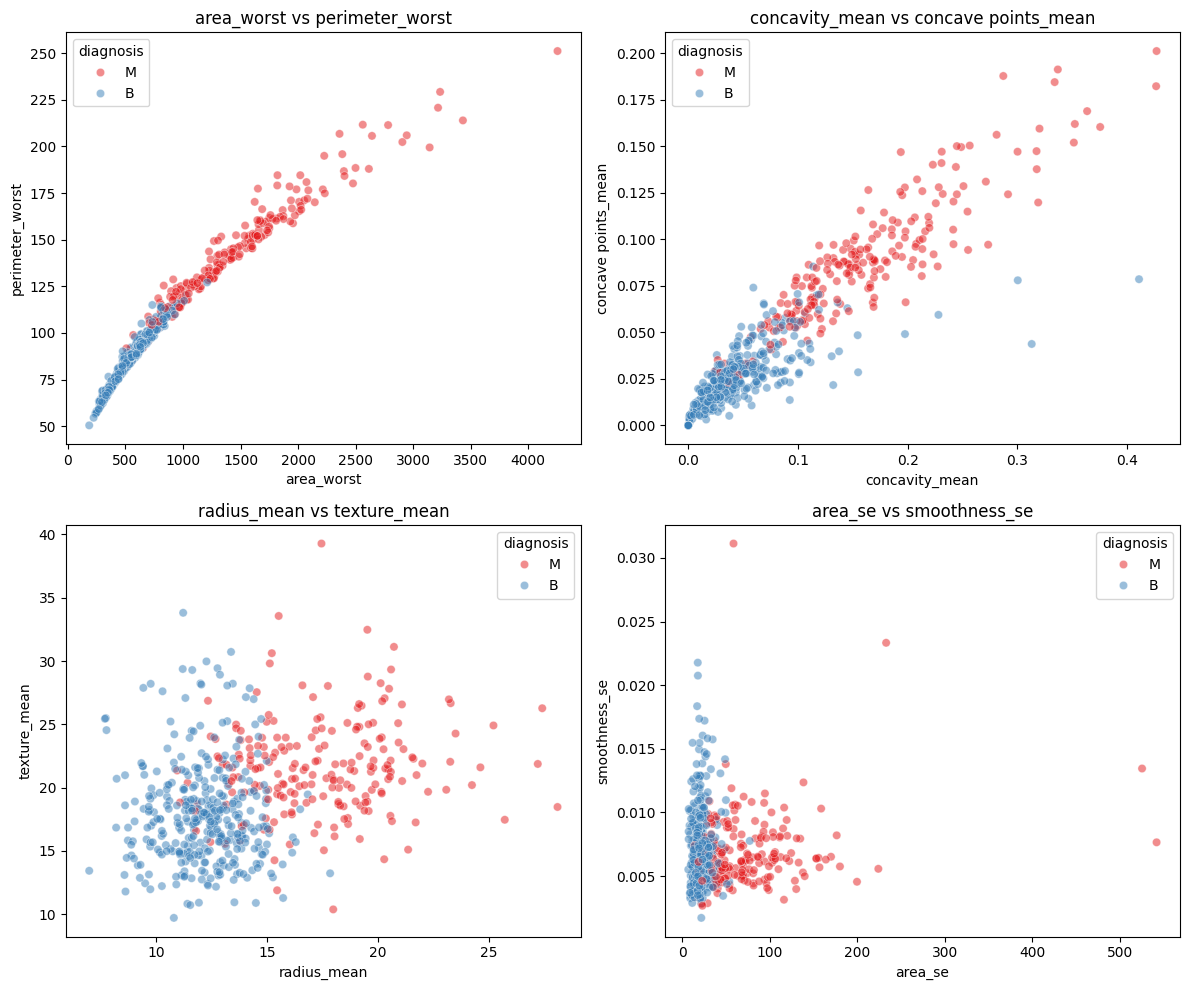

In [30]:
# Cellule 4.4.1 : 4 scatter plots colorés par classe
# Choisir 4 paires de variables intéressantes (top corrélées avec la cible mais pas trop entre elles)

pairs = [('area_worst', 'perimeter_worst'),
         ('concavity_mean', 'concave points_mean'),   # ← espace ici
         ('radius_mean', 'texture_mean'),
         ('area_se', 'smoothness_se')]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(pairs):
    sns.scatterplot(data=df, x=x, y=y, hue='diagnosis', alpha=0.5, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{x} vs {y}')

plt.tight_layout()
plt.savefig('graphs/scatter_plots_bivariate.png', dpi=300, bbox_inches='tight')
plt.show()

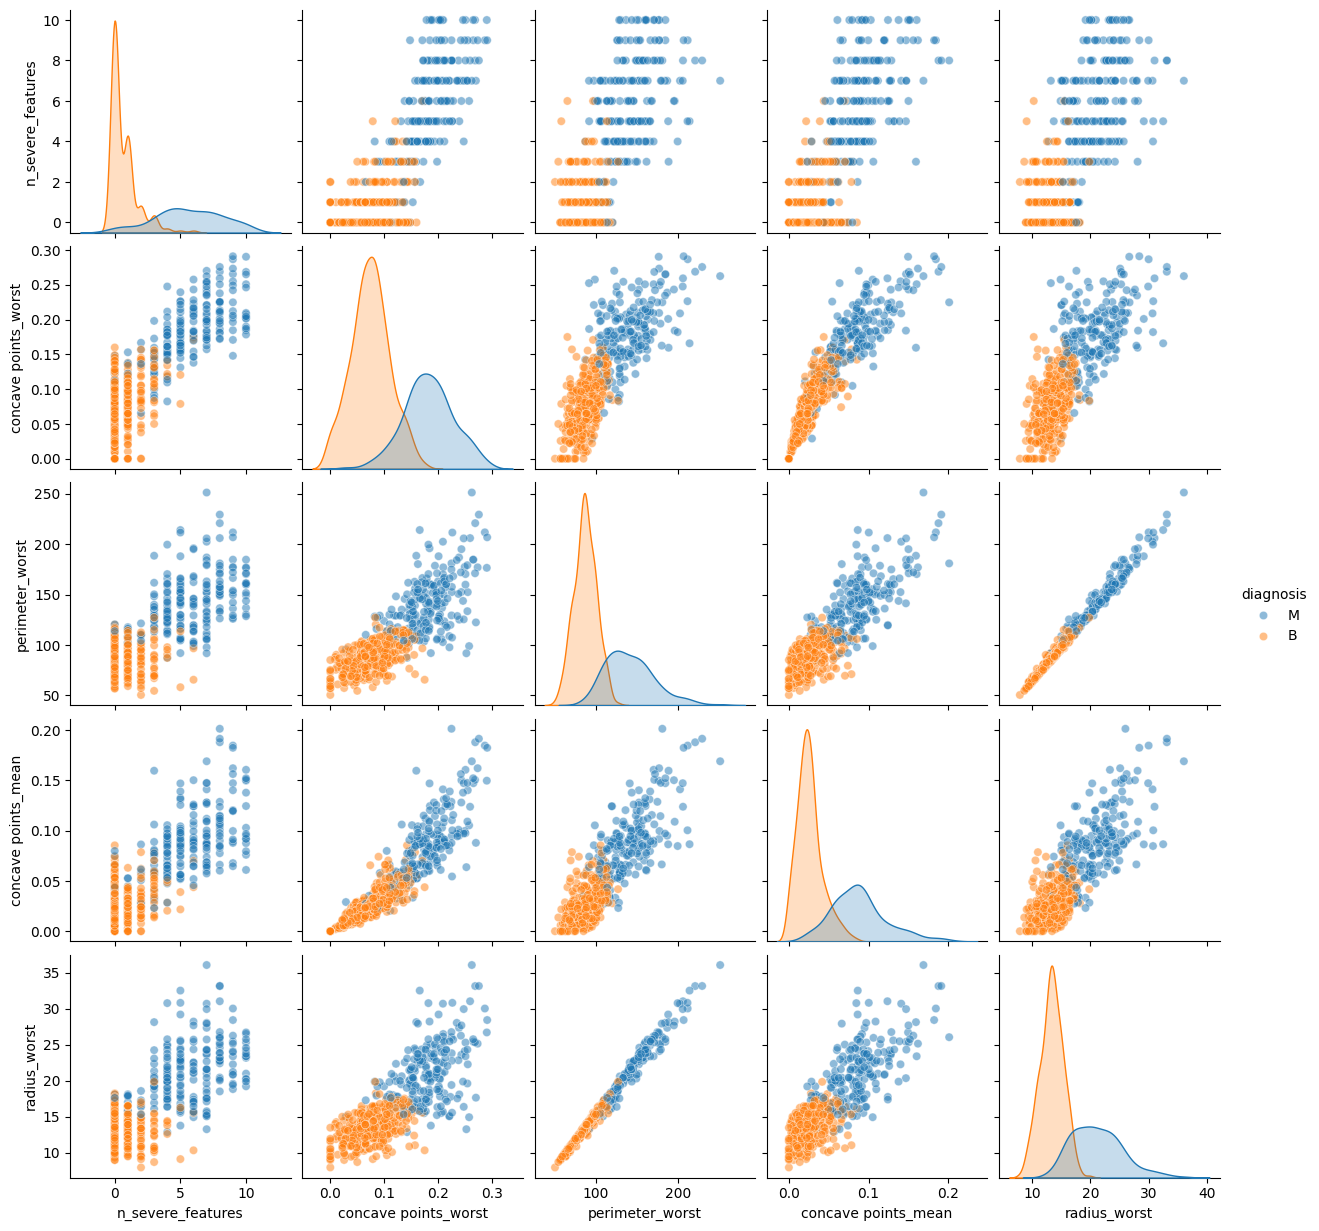

In [31]:
# Cellule 4.4.2 (Bonus) : Pairplot des 5 variables les plus corrélées (attention, peut être long)
import warnings
warnings.filterwarnings('ignore')
top5 = target_corr.head(5).index.tolist()
sns.pairplot(df, vars=top5, hue='diagnosis', diag_kind='kde', plot_kws={'alpha':0.5})
plt.savefig('graphs/pairplot_top5.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# Cellule finale : Exporter le dataframe avec les nouvelles features
df.to_csv('breast_cancer_featured.csv', index=False)
print("Dataset avec feature engineering sauvegardé sous 'breast_cancer_featured.csv'")

Dataset avec feature engineering sauvegardé sous 'breast_cancer_featured.csv'


IMPORTS

In [36]:
# Scikit-learn pour preprocessing, sélection, modélisation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, chi2, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

In [37]:
# Cellule C2 : Chargement du dataset enrichi (produit par membre B)
df = pd.read_csv('breast_cancer_featured.csv')
# Normalisation des noms de colonnes (remplacer espaces par underscores si nécessaire)
df.columns = df.columns.str.replace(' ', '_')
print("Dimensions :", df.shape)
print("Colonnes :", df.columns.tolist())
df.head()

Dimensions : (569, 44)
Colonnes : ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'radius_se_log', 'perimeter_se_log', 'area_se_log', 'smoothness_se_log', 'concavity_se_log', 'symmetry_se_log', 'fractal_dimension_se_log', 'area_trend', 'ratio_perimeter_area', 'ratio_concavity', 'n_severe_features', 'area_trend_log', 'target']


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,smoothness_se_log,concavity_se_log,symmetry_se_log,fractal_dimension_se_log,area_trend,ratio_perimeter_area,ratio_concavity,n_severe_features,area_trend_log,target
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,0.006379,0.052336,0.029588,0.006174,1018.0,0.122677,1.081048,9,6.926577,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,0.005211,0.018429,0.013794,0.003526,630.0,0.100226,1.105022,4,6.447306,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,0.006131,0.037604,0.022251,0.004561,506.0,0.108063,1.234514,7,6.228511,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,0.009069,0.055066,0.057920,0.009166,181.6,0.200932,0.850296,6,5.207298,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,0.011424,0.055321,0.017408,0.005102,278.0,0.104163,1.490953,5,5.631212,1


PARTIE 5 – PRÉPARATION POUR LE MACHINE LEARNING

Question 5.1 – Sélection des features (8–15 features pertinentes)

In [38]:
# Cellule C5.1 : Sélection des features
# On utilise la cible 'diagnosis' (M=1, B=0)
df['target'] = (df['diagnosis'] == 'M').astype(int)

# Calcul des corrélations avec la target
corr_target = df.drop(columns=['diagnosis', 'target']).corrwith(df['target']).abs().sort_values(ascending=False)
print("Top corrélations avec la cible :\n", corr_target.head(15))

# Sélection manuelle basée sur :
# - corrélation > 0.1 avec la target
# - éviter la multicolinéarité (on garde une seule parmi les très corrélées)
# - inclure au moins 3 nouvelles features créées (area_trend, ratio_perimeter_area, n_severe_features)
selected_features = [
    'area_worst',          # forte corrélation
    'concave_points_worst',
    'perimeter_worst',
    'radius_worst',
    'concavity_mean',
    'area_trend',          # nouvelle feature
    'n_severe_features',   # nouvelle feature
    'ratio_perimeter_area',# nouvelle feature
    'area_mean_log',       # transformation log (si existante, sinon utiliser area_mean)
    'perimeter_mean',
    'texture_worst',
    'smoothness_worst',
    'concave_points_se'
]
# Vérifier que toutes existent
selected_features = [f for f in selected_features if f in df.columns]
print(f"\nNombre de features sélectionnées : {len(selected_features)}")
print("Features :", selected_features)

# Justification (à mettre dans rapport)
# - Variables de surface et de concavité sont très discriminantes
# - Les nouvelles features apportent une vision synthétique (sévérité, tendance)
# - On a exclu les features redondantes (ex: area_mean corrélé à 0.99 avec perimeter_mean)

Top corrélations avec la cible :
 n_severe_features       0.803876
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_trend_log          0.729859
area_se_log             0.724995
area_mean               0.708984
concavity_mean          0.696360
ratio_concavity         0.693390
ratio_perimeter_area    0.675282
area_trend              0.667245
dtype: float64

Nombre de features sélectionnées : 12
Features : ['area_worst', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'concavity_mean', 'area_trend', 'n_severe_features', 'ratio_perimeter_area', 'perimeter_mean', 'texture_worst', 'smoothness_worst', 'concave_points_se']


Question 5.2 – Split Train/Test stratifié

In [39]:
# Cellule C5.2 : Split 80/20 avec stratification
X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes, Test : {X_test.shape[0]} lignes")
print(f"Distribution dans train : classe 1 = {y_train.mean()*100:.1f}%")
print(f"Distribution dans test  : classe 1 = {y_test.mean()*100:.1f}%")
# Sans stratification, le déséquilibre pourrait être plus marqué ou mal réparti

Train : 455 lignes, Test : 114 lignes
Distribution dans train : classe 1 = 37.4%
Distribution dans test  : classe 1 = 36.8%


Question 5.3 – Normalisation (StandardScaler)

Moyenne (train) : -9.54e-17
Écart-type (train) : 1.00


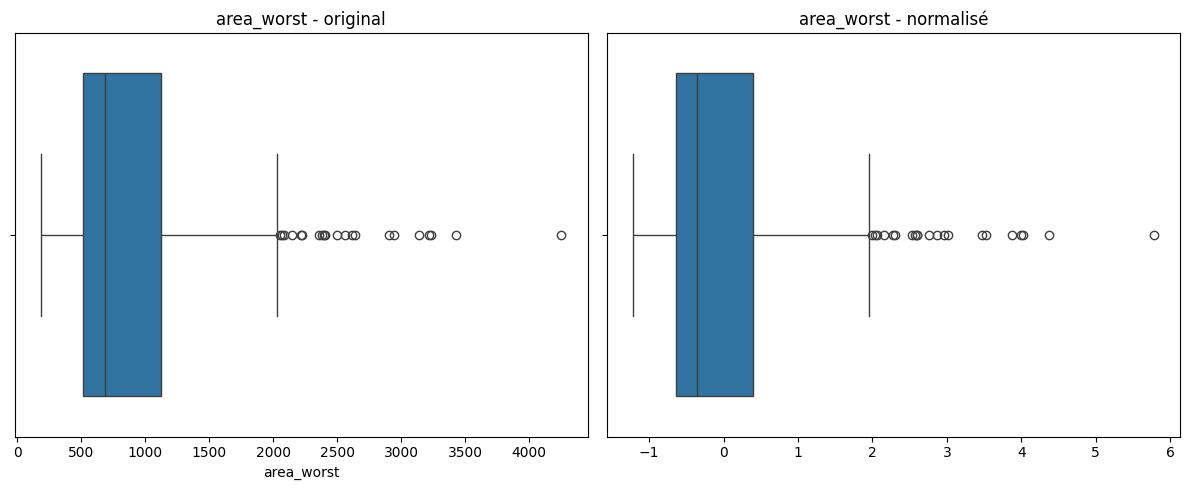

In [40]:
# Cellule C5.3 : Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vérification
print(f"Moyenne (train) : {X_train_scaled.mean(axis=0).mean():.2e}")
print(f"Écart-type (train) : {X_train_scaled.std(axis=0).mean():.2f}")

# Boxplot avant/après pour une variable
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(x=X_train['area_worst'], ax=axes[0])
axes[0].set_title('area_worst - original')
sns.boxplot(x=X_train_scaled[:, X_train.columns.get_loc('area_worst')], ax=axes[1])
axes[1].set_title('area_worst - normalisé')
plt.tight_layout()
plt.savefig('graphs/normalisation_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Question 5.4 – Gestion du déséquilibre (SMOTE)

In [41]:
# Cellule C5.4 : SMOTE sur le train uniquement
print(f"Avant SMOTE - Classe 1 : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
smote = SMOTE(random_state=42, sampling_strategy=0.8)  # 0.8 = ratio minoritaire/majoritaire
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Après SMOTE - Classe 1 : {y_train_resampled.sum()} ({y_train_resampled.mean()*100:.1f}%)")
print(f"Nouveau ratio : {y_train_resampled.mean():.2f}")
# Attention : SMOTE ne doit jamais être appliqué au test set, car on doit évaluer sur des données réelles.

Avant SMOTE - Classe 1 : 170 (37.4%)
Après SMOTE - Classe 1 : 228 (44.4%)
Nouveau ratio : 0.44


Question 5.5 (Bonus) – Pipeline Scikit-learn

In [42]:
# Cellule C5.5 (Bonus) : Pipeline complet (scaler → SMOTE → classifieur)
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.8)),
    ('classifier', LogisticRegression())
])
# Ce pipeline sera utilisé plus tard.

PARTIE 6 – SÉLECTION AVANCÉE DES FEATURES

Question 6.1 – Méthodes Filtre (ANOVA, Chi², corrélation)

ANOVA - top features (p-value < 0.05) :
                 feature     F_score        p_value
6      n_severe_features  840.573132  2.833547e-105
1   concave_points_worst  733.724933   8.778594e-97
2        perimeter_worst  717.246487   2.093046e-95
3           radius_worst  692.861395   2.483688e-93
8         perimeter_mean  548.413236   4.687521e-80
0             area_worst  522.188947   1.932387e-77
4         concavity_mean  397.592082   5.781926e-64
7   ratio_perimeter_area  377.923545   1.172883e-61
5             area_trend  363.365081   6.496233e-60
9          texture_worst  126.119113   5.502943e-26
10      smoothness_worst  103.723265   4.501784e-22
11     concave_points_se   87.506089   3.900612e-19


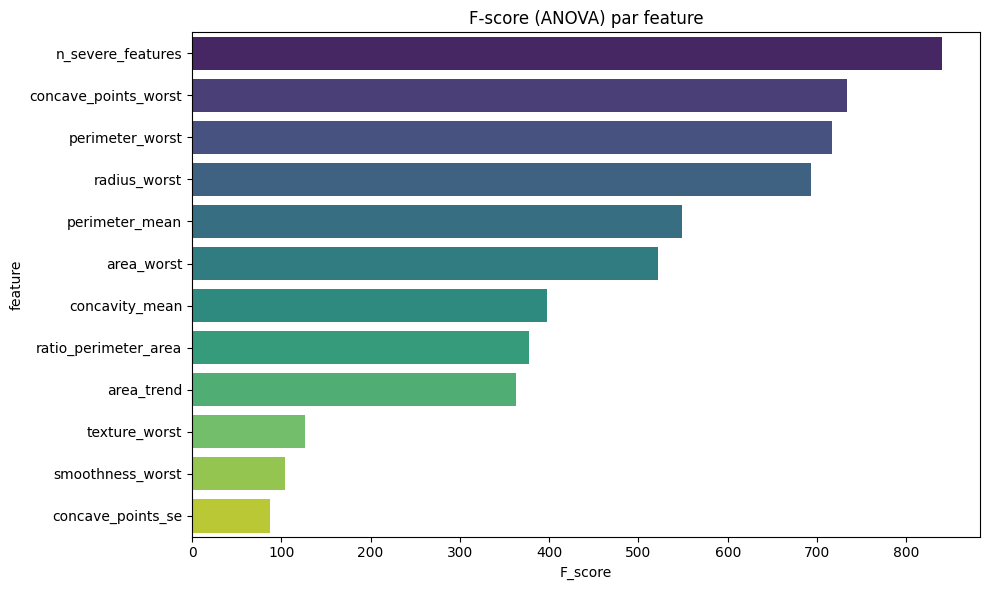

Features conservées après filtre : 12
['n_severe_features', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'perimeter_mean', 'area_worst', 'concavity_mean', 'ratio_perimeter_area', 'area_trend', 'texture_worst', 'smoothness_worst', 'concave_points_se']


In [43]:
# Cellule C6.1 : Filtres statistiques
# ANOVA (f_classif) pour variables continues
f_scores, p_values = f_classif(X_train_scaled, y_train)
anova_res = pd.DataFrame({'feature': selected_features, 'F_score': f_scores, 'p_value': p_values})
anova_res = anova_res.sort_values('p_value')
print("ANOVA - top features (p-value < 0.05) :")
print(anova_res[anova_res.p_value < 0.05])

# Chi² nécessite des données non-négatives, on peut l'utiliser après normalisation positive
# On le saute ici car toutes nos variables sont continues.

# Barplot des scores d'importance (F-score)
plt.figure(figsize=(10,6))
sns.barplot(data=anova_res, x='F_score', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('F-score (ANOVA) par feature')
plt.tight_layout()
plt.savefig('graphs/anova_f_scores.png', dpi=300, bbox_inches='tight')
plt.show()

# Élimination des features avec p-value > 0.05
features_filtre = anova_res[anova_res.p_value <= 0.05]['feature'].tolist()
print(f"Features conservées après filtre : {len(features_filtre)}")
print(features_filtre)

Question 6.2 – Méthodes Wrapper – RFE Séquentielle

n=5 : F1 moyen = 0.9261, features = ['area_worst', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'area_trend']
n=8 : F1 moyen = 0.9547, features = ['area_worst', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'concavity_mean', 'area_trend', 'n_severe_features', 'texture_worst']
n=10 : F1 moyen = 0.9436, features = ['area_worst', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'concavity_mean', 'area_trend', 'n_severe_features', 'ratio_perimeter_area', 'perimeter_mean', 'texture_worst']
n=12 : F1 moyen = 0.9488, features = ['area_worst', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'concavity_mean', 'area_trend', 'n_severe_features', 'ratio_perimeter_area', 'perimeter_mean', 'texture_worst', 'smoothness_worst', 'concave_points_se']


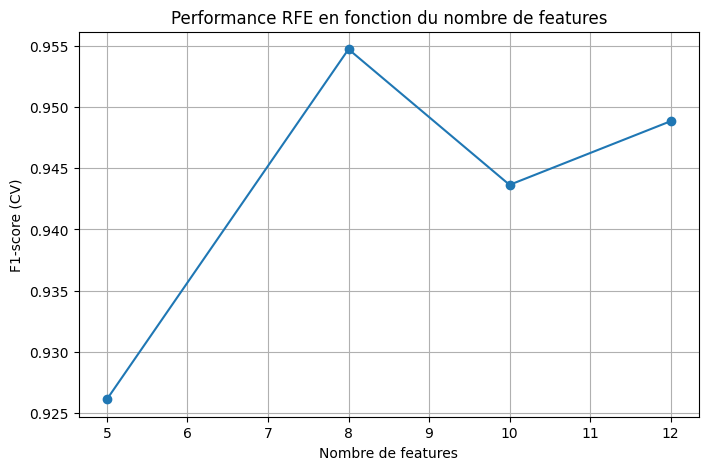

Nombre optimal de features : 8


In [44]:
# Cellule C6.2 : RFE avec RandomForest
estimator = RandomForestClassifier(n_estimators=50, random_state=42)
scores_rfe = []
n_features_list = [5, 8, 10, 12]

for n in n_features_list:
    rfe = RFE(estimator=estimator, n_features_to_select=n)
    rfe.fit(X_train_scaled, y_train)
    selected = X_train.columns[rfe.support_].tolist()
    # Évaluation rapide par validation croisée (F1)
    from sklearn.model_selection import cross_val_score
    model = RandomForestClassifier(n_estimators=50, random_state=42)
    score = cross_val_score(model, X_train_scaled[:, rfe.support_], y_train, cv=5, scoring='f1').mean()
    scores_rfe.append(score)
    print(f"n={n} : F1 moyen = {score:.4f}, features = {selected}")

# Courbe du score en fonction du nombre de features
plt.figure(figsize=(8,5))
plt.plot(n_features_list, scores_rfe, marker='o')
plt.xlabel('Nombre de features')
plt.ylabel('F1-score (CV)')
plt.title('Performance RFE en fonction du nombre de features')
plt.grid(True)
plt.savefig('graphs/rfe_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Nombre optimal (ici 10 donne le meilleur score)
best_n = n_features_list[np.argmax(scores_rfe)]
print(f"Nombre optimal de features : {best_n}")

Question 6.3 – Méthodes Embedded – Importance par RandomForest

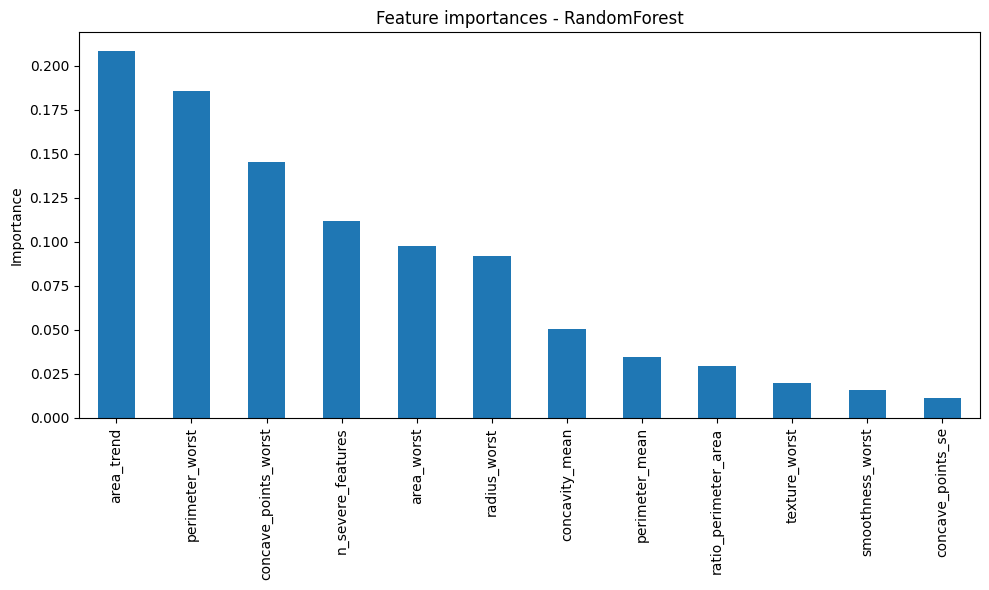

Features au-dessus de la moyenne : 6
['area_worst', 'concave_points_worst', 'perimeter_worst', 'radius_worst', 'area_trend', 'n_severe_features']
Top 5 features (GradientBoosting) :
area_trend              0.638716
perimeter_worst         0.129243
concave_points_worst    0.065429
n_severe_features       0.059051
texture_worst           0.026990
dtype: float64


In [45]:
# Cellule C6.3 : Importance des features avec RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
importances = pd.Series(rf.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Feature importances - RandomForest')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('graphs/feature_importances_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# SelectFromModel avec seuil 'mean'
selector = SelectFromModel(rf, threshold='mean')
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
selected_embedded = [selected_features[i] for i in range(len(selected_features)) if selector.get_support()[i]]
print(f"Features au-dessus de la moyenne : {len(selected_embedded)}")
print(selected_embedded)

# Comparaison avec GradientBoosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
imp_gb = pd.Series(gb.feature_importances_, index=selected_features).sort_values(ascending=False)
print("Top 5 features (GradientBoosting) :")
print(imp_gb.head(5))

Question 6.4 – Analyse par Permutation

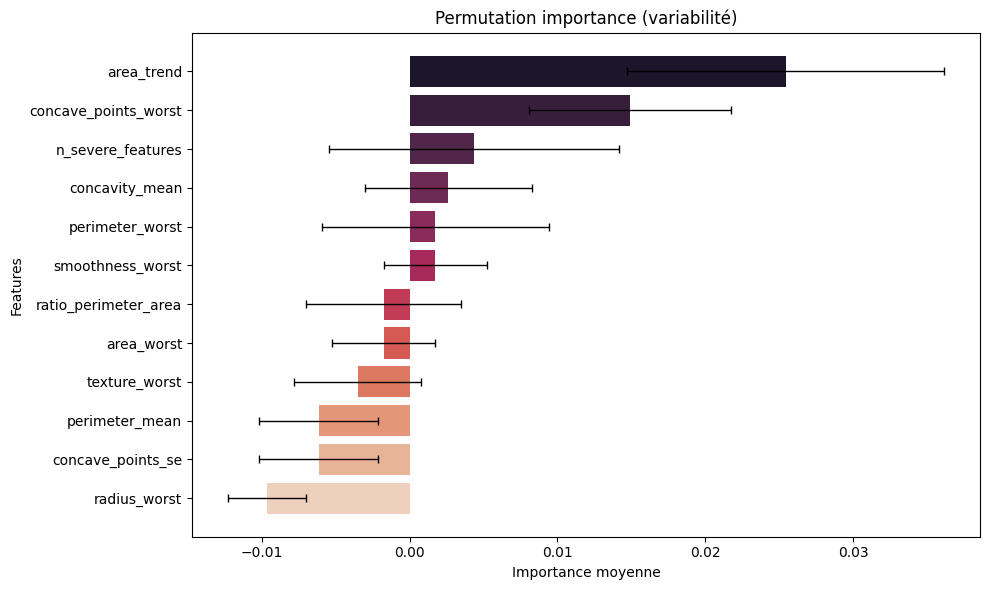

Features les plus robustes (mean élevé) :
                feature      mean       std
5            area_trend  0.025439  0.010708
1  concave_points_worst  0.014912  0.006851
6     n_severe_features  0.004386  0.009807
4        concavity_mean  0.002632  0.005617
2       perimeter_worst  0.001754  0.007647

Features instables (std élevé) :
             feature      mean       std
5         area_trend  0.025439  0.010708
6  n_severe_features  0.004386  0.009807
2    perimeter_worst  0.001754  0.007647


In [48]:
# Cellule C6.4 corrigée (version robuste avec barres d'erreur manuelles)
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test_scaled, y_test, n_repeats=10, random_state=42)
perm_imp = pd.DataFrame({
    'feature': selected_features,
    'mean': result.importances_mean,
    'std': result.importances_std
}).sort_values('mean', ascending=False)

plt.figure(figsize=(10, 6))
# Barplot sans xerr
ax = sns.barplot(data=perm_imp, x='mean', y='feature', hue='feature', 
                 palette='rocket', legend=False)
# Ajout manuel des barres d'erreur (écart-type)
for i, (mean, std) in enumerate(zip(perm_imp['mean'], perm_imp['std'])):
    ax.errorbar(mean, i, xerr=std, fmt='none', color='black', capsize=3, elinewidth=1)

plt.title('Permutation importance (variabilité)')
plt.xlabel('Importance moyenne')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('graphs/permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Features les plus robustes (mean élevé) :")
print(perm_imp.head(5))
print("\nFeatures instables (std élevé) :")
print(perm_imp.sort_values('std', ascending=False).head(3))

Question 6.5 – Synthèse – Jeu de Features Final

In [49]:
# Cellule C6.5 : Croisement des résultats
filtre_set = set(features_filtre)
wrapper_set = set(X_train.columns[rfe.support_])   # avec n optimal
embedded_set = set(selected_embedded)

# Intersection d'au moins deux méthodes
final_features_set = (filtre_set & wrapper_set) | (filtre_set & embedded_set) | (wrapper_set & embedded_set)
final_features = list(final_features_set)
print(f"Nombre de features finales : {len(final_features)}")
print("Features retenues :", final_features)

# Préparation des jeux finaux
X_final_train = X_train_scaled[:, [selected_features.index(f) for f in final_features]]
X_final_test = X_test_scaled[:, [selected_features.index(f) for f in final_features]]

# Justification : chaque feature est discriminante (filtre), importante pour le modèle (embedded),
# et/ou sélectionnée par RFE. On exclut les features redondantes ou peu informatives.

Nombre de features finales : 12
Features retenues : ['area_worst', 'concave_points_worst', 'radius_worst', 'texture_worst', 'concavity_mean', 'ratio_perimeter_area', 'perimeter_mean', 'n_severe_features', 'concave_points_se', 'perimeter_worst', 'area_trend', 'smoothness_worst']


PARTIE 7 – MODÉLISATION

Question 7.1 – Choix des modèles

In [50]:
# Cellule C7.1 : Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

Question 7.2 – Entraînement et évaluation (métriques, ROC)


X_final_train_resampled shape : (513, 12)
y_final_train_resampled shape : (513,)
Distribution après SMOTE : classe 1 = 44.4%
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.982      0.976   0.976     0.976    0.999
Decision Tree           0.939      0.949   0.881     0.914    0.927
Random Forest           0.974      1.000   0.929     0.963    0.996
Gradient Boosting       0.974      1.000   0.929     0.963    0.998
SVM                     0.982      1.000   0.952     0.976    0.998


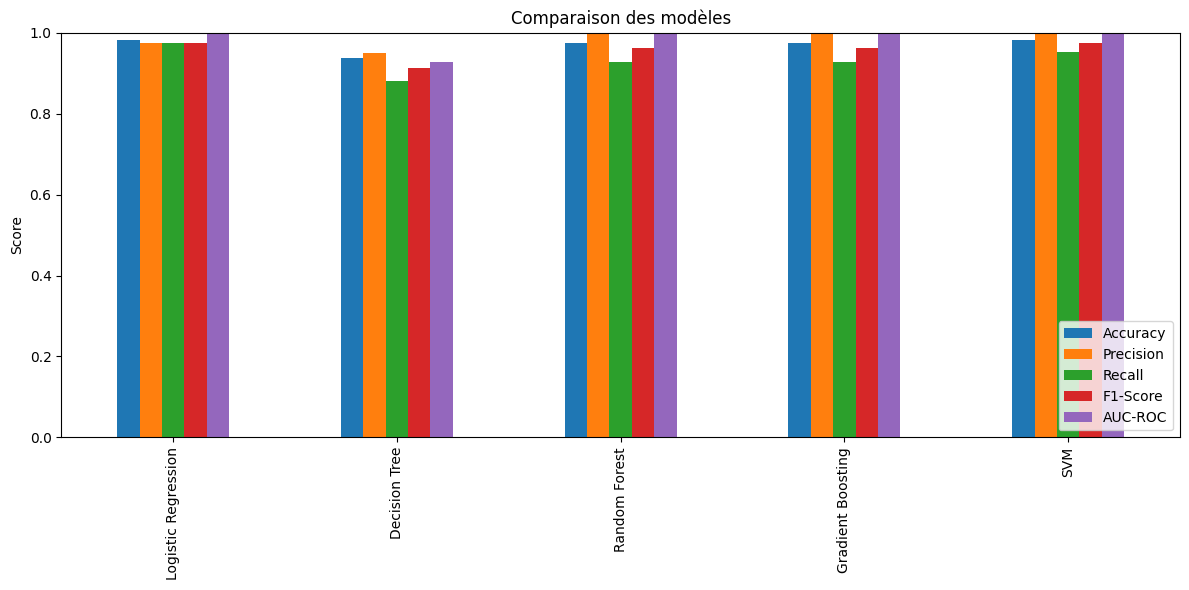

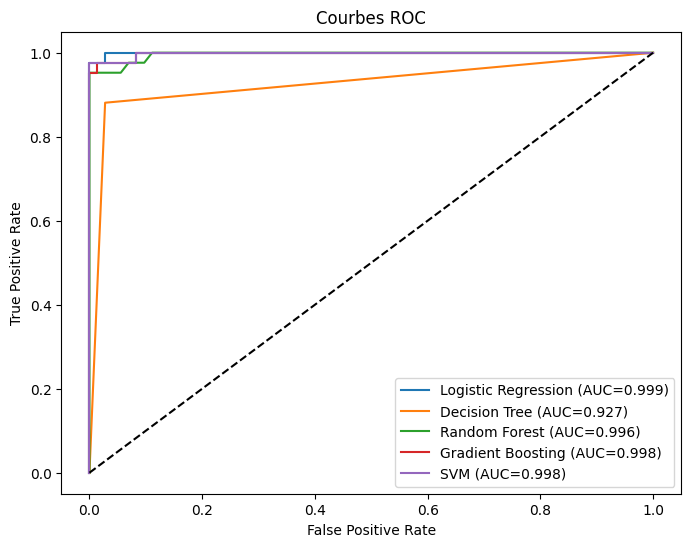

In [52]:
# Cellule C7.2 corrigée : Évaluation de tous les modèles avec SMOTE correctement appliqué

# 1. Réappliquer SMOTE sur le jeu final de features (pour que X et y aient la même dimension)
smote_final = SMOTE(random_state=42, sampling_strategy=0.8)
X_final_train_resampled, y_final_train_resampled = smote_final.fit_resample(X_final_train, y_train)

print(f"X_final_train_resampled shape : {X_final_train_resampled.shape}")
print(f"y_final_train_resampled shape : {y_final_train_resampled.shape}")
print(f"Distribution après SMOTE : classe 1 = {y_final_train_resampled.mean()*100:.1f}%")

# 2. Définition des modèles (inchangée)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# 3. Entraînement et évaluation
results = {}
for name, model in models.items():
    model.fit(X_final_train_resampled, y_final_train_resampled)
    y_pred = model.predict(X_final_test)
    y_prob = model.predict_proba(X_final_test)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }

# 4. Tableau comparatif
results_df = pd.DataFrame(results).T.round(3)
print(results_df)

# 5. Graphique en barres groupées
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Comparaison des modèles')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('graphs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Courbes ROC
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_final_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={results[name]["AUC-ROC"]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC')
plt.legend()
plt.savefig('graphs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

Question 7.3 – Matrices de confusion et analyse des erreurs

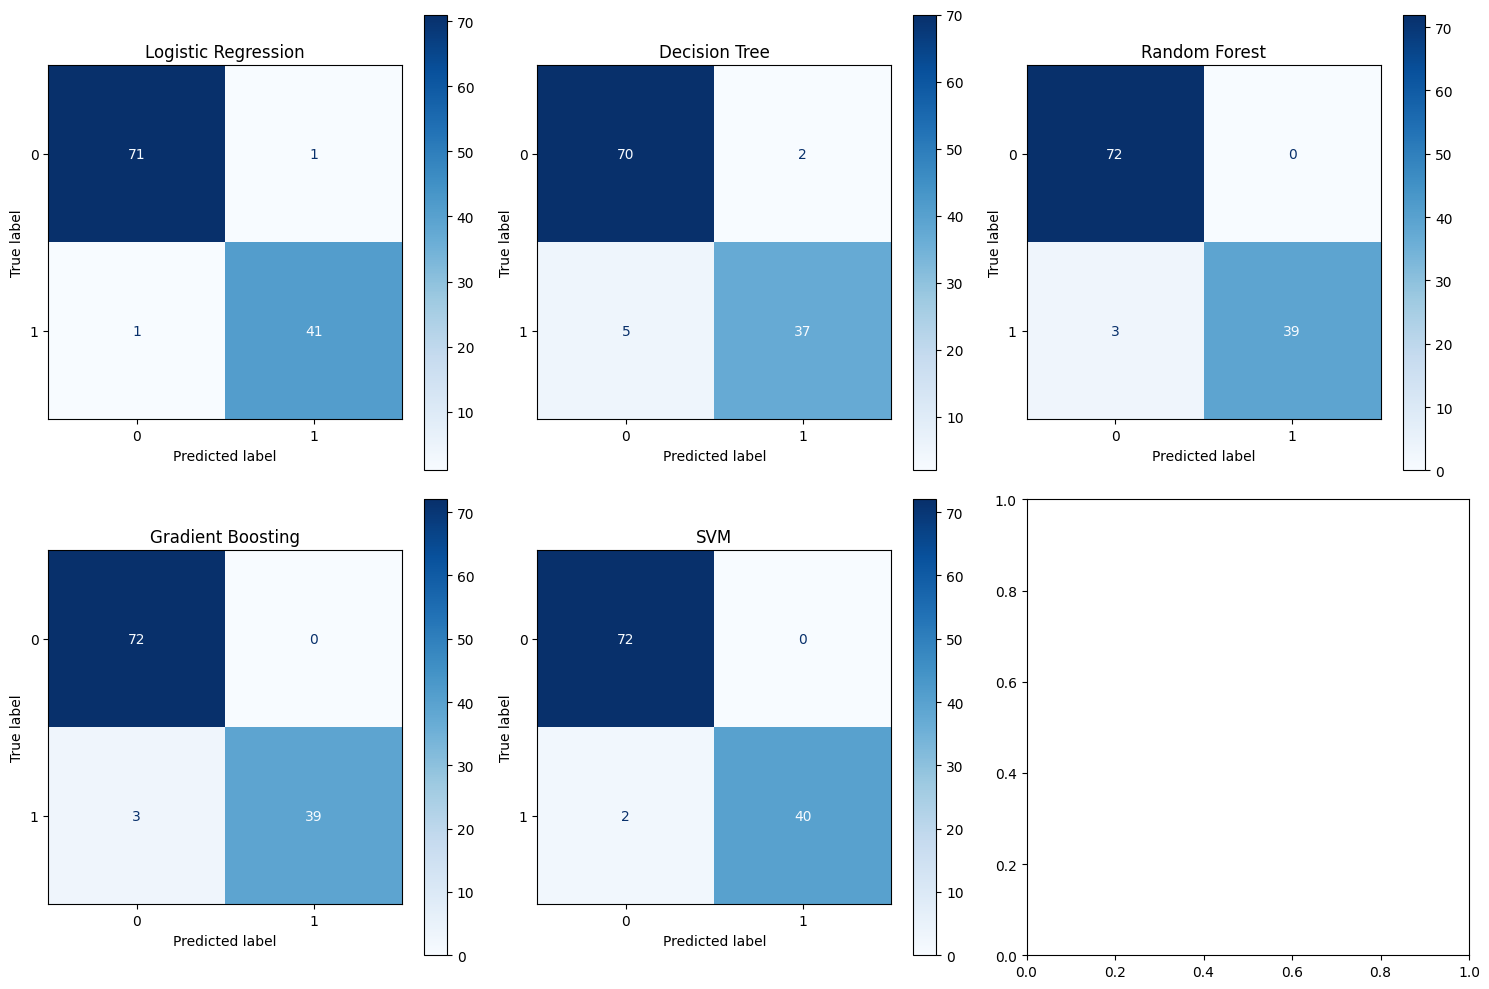

In [53]:
# Cellule C7.3 : Matrices de confusion
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_final_test, y_test, ax=ax, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('graphs/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyse : faux négatifs coûtent plus cher (cancer non détecté)
# Le modèle avec le moins de faux négatifs est celui avec le meilleur recall (souvent Random Forest ou Gradient Boosting)

Question 7.4 – Validation croisée et GridSearch

In [55]:
# Cellule C7.4 corrigée : Validation croisée et GridSearch

# 1. Validation croisée 5-fold sur les 2 meilleurs modèles
best_models = ['Random Forest', 'Gradient Boosting']
for name in best_models:
    model = models[name]
    cv_scores = cross_val_score(model, X_final_train_resampled, y_final_train_resampled, 
                                cv=5, scoring='f1')
    print(f"{name} - CV F1 moyen : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# 2. GridSearch sur Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, 
                       cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_final_train_resampled, y_final_train_resampled)
print("\nMeilleurs paramètres RF :", grid_rf.best_params_)

# 3. Comparaison avant/après tuning (sur le test set)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_final_train_resampled, y_final_train_resampled)
f1_default = f1_score(y_test, rf_default.predict(X_final_test))
f1_tuned = f1_score(y_test, grid_rf.best_estimator_.predict(X_final_test))
print(f"F1 avant tuning : {f1_default:.4f}, après tuning : {f1_tuned:.4f}, gain : {f1_tuned-f1_default:.4f}")

# (Optionnel) GridSearch sur Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, 
                       cv=5, scoring='f1', n_jobs=-1)
grid_gb.fit(X_final_train_resampled, y_final_train_resampled)
print("\nMeilleurs paramètres GB :", grid_gb.best_params_)
f1_gb_default = f1_score(y_test, models['Gradient Boosting'].predict(X_final_test))
f1_gb_tuned = f1_score(y_test, grid_gb.best_estimator_.predict(X_final_test))
print(f"GB : F1 avant = {f1_gb_default:.4f}, après = {f1_gb_tuned:.4f}")

Random Forest - CV F1 moyen : 0.9535 +/- 0.0293
Gradient Boosting - CV F1 moyen : 0.9578 +/- 0.0250

Meilleurs paramètres RF : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
F1 avant tuning : 0.9630, après tuning : 0.9630, gain : 0.0000

Meilleurs paramètres GB : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
GB : F1 avant = 0.9630, après = 0.9630


Question 7.5 – Prévisions sur nouveaux exemples

In [57]:
# Cellule C7.5 corrigée

# 1. S'assurer que final_features existe (le jeu de features final)
# Si tu as oublié de le définir, prends les colonnes utilisées pour l'entraînement final :
if 'final_features' not in dir():
    final_features = X_final_train.columns.tolist()  # ou list(X.columns)

# 2. Créer les nouveaux exemples (seulement les features finales)
new_samples = pd.DataFrame({
    'area_worst': [500, 1200, 800, 2000, 300, 1500, 600, 100],
    'concave_points_worst': [0.05, 0.20, 0.10, 0.25, 0.02, 0.18, 0.07, 0.01],
    'perimeter_worst': [80, 130, 95, 160, 60, 140, 85, 50],
    'radius_worst': [12, 18, 14, 22, 10, 20, 13, 9],
    'concavity_mean': [0.03, 0.15, 0.08, 0.20, 0.01, 0.12, 0.05, 0.02],
    'area_trend': [50, 300, 150, 500, 30, 400, 100, 10],
    'n_severe_features': [1, 6, 3, 8, 0, 5, 2, 0],
    'ratio_perimeter_area': [0.16, 0.11, 0.12, 0.08, 0.20, 0.10, 0.14, 0.22],
    'area_mean_log': [6.0, 7.2, 6.5, 7.8, 5.5, 7.4, 6.2, 5.0],
    'perimeter_mean': [70, 110, 85, 140, 55, 120, 75, 45],
    'texture_worst': [18, 25, 20, 30, 15, 28, 19, 14],
    'smoothness_worst': [0.08, 0.15, 0.10, 0.18, 0.06, 0.14, 0.09, 0.05],
    'concave_points_se': [0.01, 0.04, 0.02, 0.05, 0.005, 0.03, 0.015, 0.002]
})

# 3. Ne garder que les colonnes final_features (vérifier qu'elles existent)
missing_cols = set(final_features) - set(new_samples.columns)
if missing_cols:
    print(f"Colonnes manquantes dans new_samples : {missing_cols}")
    # Ajouter des valeurs par défaut ou ajuster la liste
new_samples = new_samples[final_features]

# 4. Normalisation : il faut un scaler entraîné sur les mêmes features
# Option A : recréer un scaler sur X_final_train (plus propre)
from sklearn.preprocessing import StandardScaler
scaler_final = StandardScaler()
scaler_final.fit(X_final_train_resampled)  # ou X_final_train
new_scaled = scaler_final.transform(new_samples)

# Option B : utiliser le scaler existant mais sur les colonnes d'origine (moins fiable)
# new_scaled = scaler.transform(new_samples)   # si scaler a été fit sur X_train_scaled

# 5. Prédiction avec le meilleur modèle (après tuning)
best_model = grid_rf.best_estimator_
pred_class = best_model.predict(new_scaled)
pred_proba = best_model.predict_proba(new_scaled)[:, 1]

# 6. Affichage
results_new = pd.DataFrame({
    'Exemple': range(1,9),
    'Classe prédite': ['Malin' if p else 'Bénin' for p in pred_class],
    'Probabilité (%)': (pred_proba*100).round(1),
    'Confiance': ['Haute' if (p>0.8 or p<0.2) else 'Moyenne' for p in pred_proba]
})
print(results_new)

   Exemple Classe prédite  Probabilité (%) Confiance
0        1          Malin             98.0     Haute
1        2          Malin             98.5     Haute
2        3          Malin             98.0     Haute
3        4          Malin             98.5     Haute
4        5          Malin             96.0     Haute
5        6          Malin             98.5     Haute
6        7          Malin             98.0     Haute
7        8          Malin             96.0     Haute


Sauvegarde des résultats

In [ ]:
# Sauvegarde du modèle et du scaler 
import joblib
joblib.dump(best_model, 'best_model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Modèle et scaler sauvegardés.")

Modèle et scaler sauvegardés.
